# DAPI Image Display Debugging

This notebook mimics the logic used in FishGUI for loading and displaying DAPI (or other grayscale) images. It helps debug issues with z-projected images.

In [4]:
# Imports
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pathlib

## Helper: Grayscale to RGB (as in FishGUI)
This function mimics the grayscale-to-RGB conversion logic.

In [5]:
def grayscale_to_rgb(grayscale_img):
    # Squeeze singleton dimension if present
    if grayscale_img.ndim == 3 and grayscale_img.shape[0] == 1:
        grayscale_img = np.squeeze(grayscale_img, axis=0)
    # Normalize to 0-255
    img_normalized = cv2.normalize(grayscale_img, None, 0, 255, cv2.NORM_MINMAX)
    img_normalized = img_normalized.astype(np.uint8)
    img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2RGB)
    return img_rgb

## Load Image
Change the path below to your DAPI/z-projected image.

In [9]:
# Provide the path to your image file here
single_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML\FISH-ML\assets\DAPI_issue\MAX_KD1_w1-358 DAPI_s001.tif')  # <-- Change this
zprojected_DAPI = pathlib.Path(r'C:\Users\tkpp2\Documents\FISH-ML\FISH-ML\assets\DAPI_issue\MAX_KD1_w1-358 reDAPI_s001.tif')
# Load image using PIL (as in FishGUI)
single_pil = Image.open(single_DAPI)
zprojected_pil = Image.open(zprojected_DAPI)

single_np = np.array(single_pil)
print('Loaded image shape:', single_np.shape, 'dtype:', single_np.dtype, 'min:', single_np.min(), 'max:', single_np.max())
zprojected_np = np.array(zprojected_pil)
print('Loaded image shape:', zprojected_np.shape, 'dtype:', zprojected_np.dtype, 'min:', zprojected_np.min(), 'max:', zprojected_np.max())


Loaded image shape: (2048, 2048) dtype: uint16 min: 59 max: 4889
Loaded image shape: (2048, 2048) dtype: uint16 min: 100 max: 6144


## Convert to RGB and Display

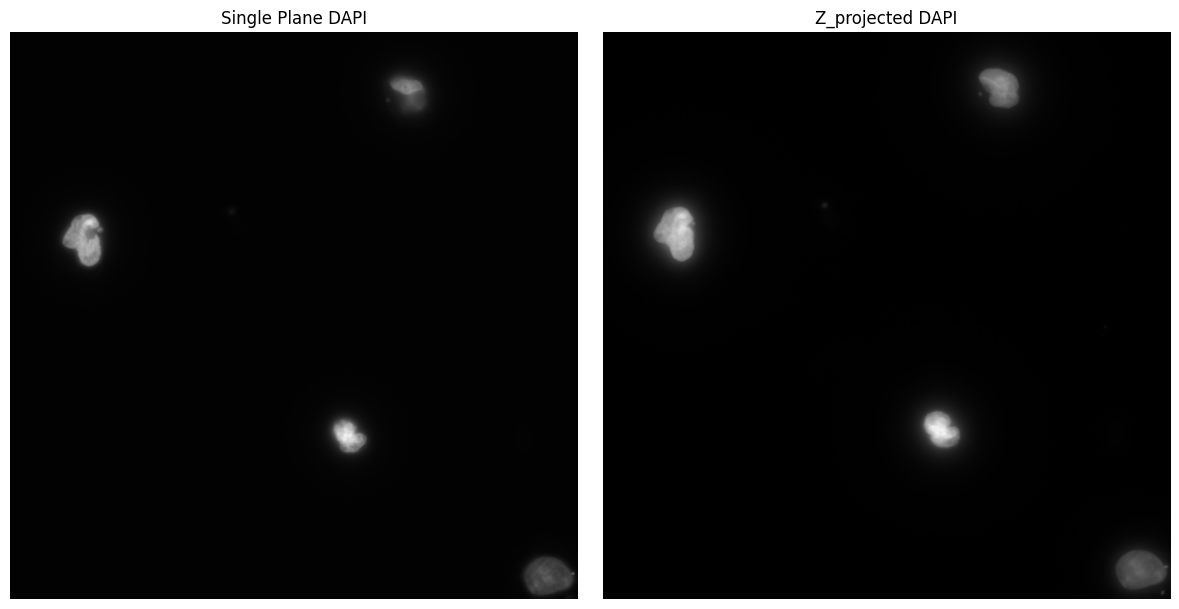

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
single_rgb = grayscale_to_rgb(single_np)
zprojected_rgb = grayscale_to_rgb(zprojected_np)

axes[0].imshow(single_rgb)
axes[0].set_title('Single Plane DAPI')
axes[0].axis('off')

axes[1].imshow(zprojected_rgb)
axes[1].set_title('Z_projected DAPI')
axes[1].axis('off')

plt.tight_layout()
plt.show()


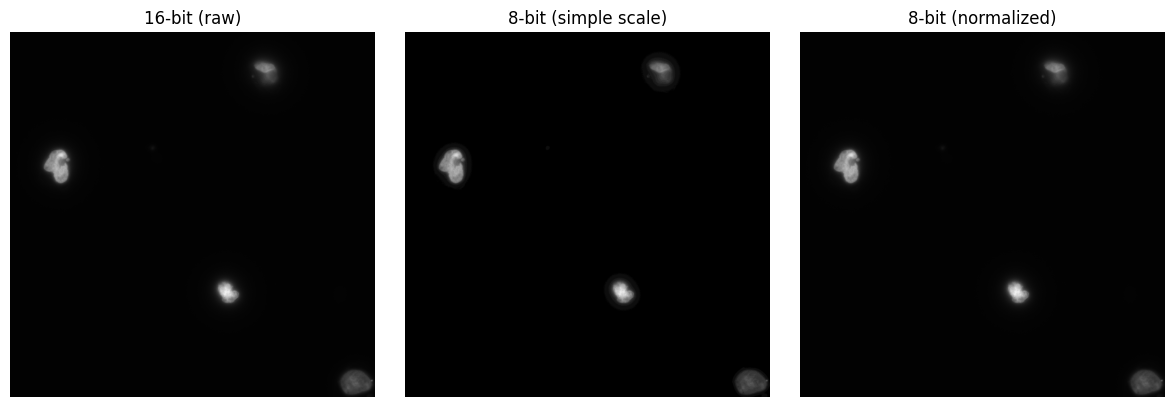

In [14]:
# Simulate 16-bit vs 8-bit display

# Assume single_np is your 16-bit image (dtype=np.uint16)
# If your image is already 8-bit, you can skip the conversion

# 1. Display the original 16-bit image (matplotlib will auto-scale)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(single_np, cmap='gray')
plt.title('16-bit (raw)')
plt.axis('off')

# 2. Convert to 8-bit by simple division (may lose contrast)
img_8bit_simple = (single_np / 256).astype(np.uint8)
plt.subplot(1, 3, 2)
plt.imshow(img_8bit_simple, cmap='gray')
plt.title('8-bit (simple scale)')
plt.axis('off')

# 3. Convert to 8-bit by normalization (preserves contrast)
img_8bit_norm = cv2.normalize(single_np, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.subplot(1, 3, 3)
plt.imshow(img_8bit_norm, cmap='gray')
plt.title('8-bit (normalized)')
plt.axis('off')

plt.tight_layout()
plt.show()